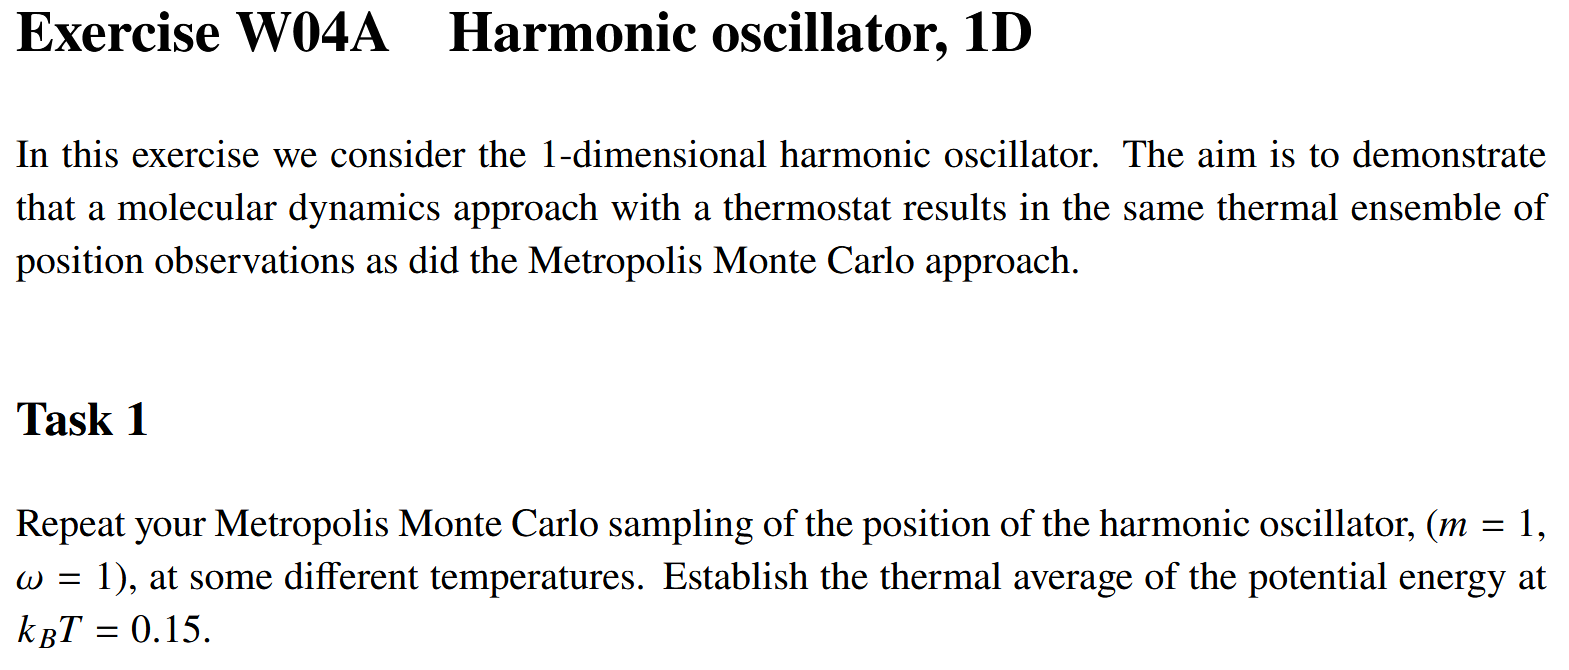

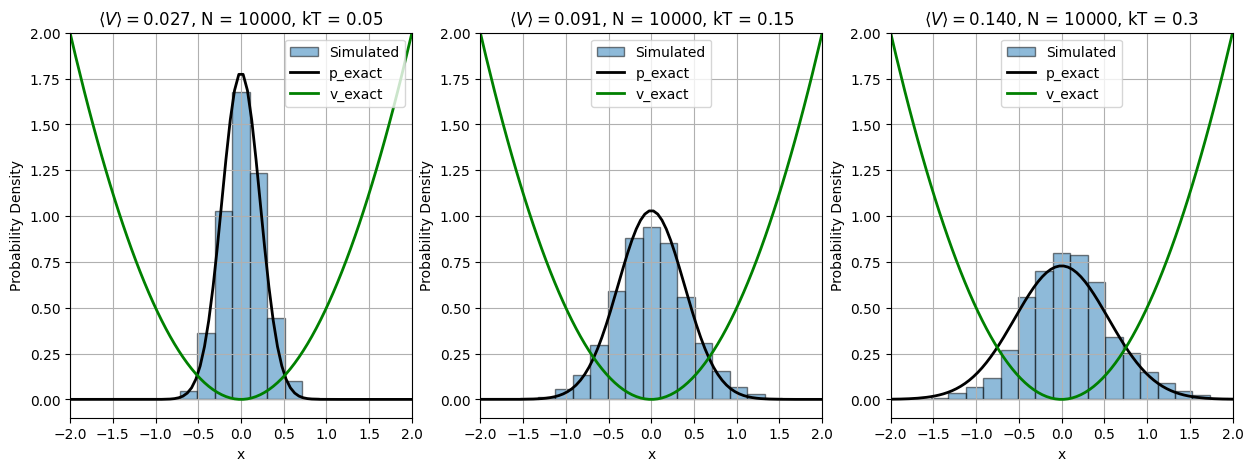

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Metropolis import *

class Harmonic():
    def __init__(self, m=1, ω=1):
        self.m = m
        self.ω = ω

    def V(self, state):
        return 0.5*self.m*(self.ω*state)**2

    def F(self, state):
        return -self.m*self.ω**2*state

calc = Harmonic()
fig, axes = plt.subplots(1,3, figsize=(15, 5))
for ax, kT in zip(axes, [0.05, 0.15, 0.3]):
    met = Metropolis(calc, 0, kT)
    met.run()
    met.plot(ax)
    ax.set_ylim(-0.1, 2)
    ax.set_xlim(-2, 2)
    ax.set_title(ax.get_title() + f', kT = {kT}')

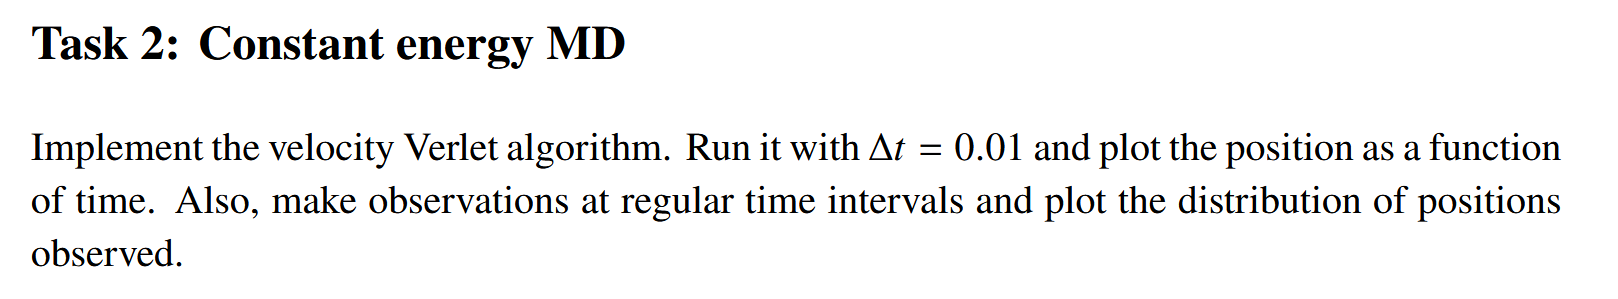
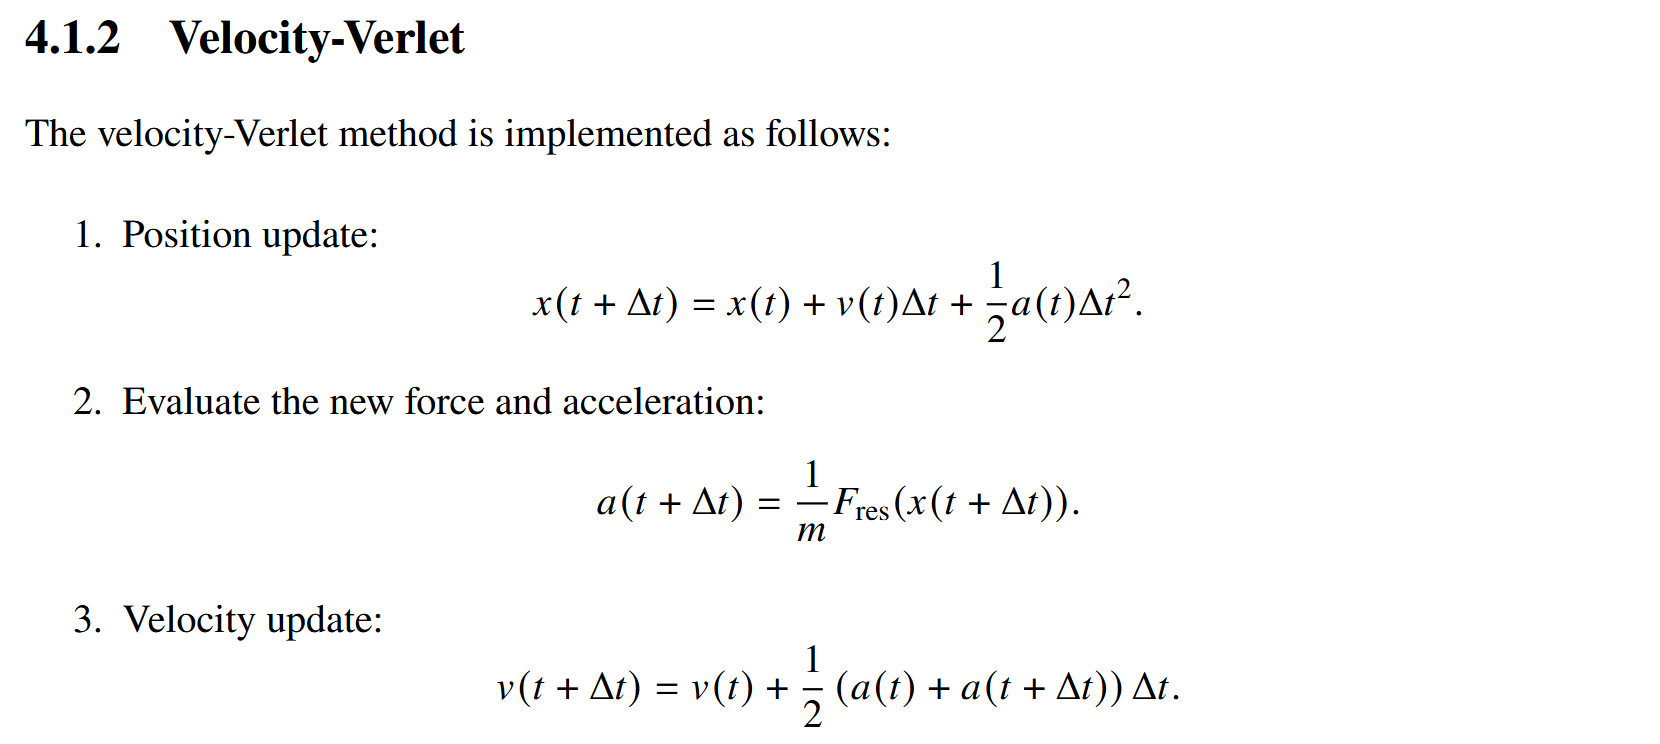

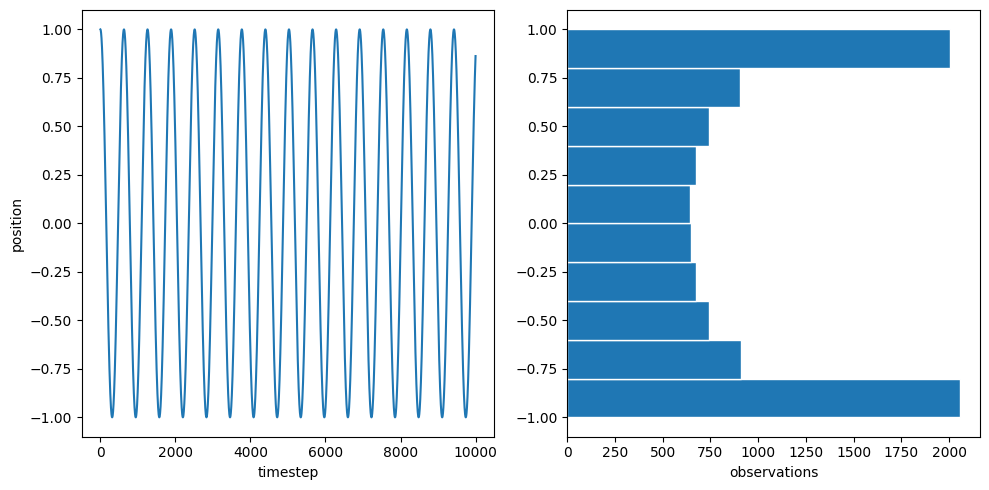

In [2]:
class MolDynSys():
    def __init__(self, calc, x=0, kT=0.15):
        self.calc = calc
        self.x = x
        self.v = 0
        self.kT = kT

    def V(self, x):
        return self.calc.V(x)

    def F(self, x):
        return self.calc.F(x)

    def get_position(self):
        return self.x

    def set_position(self, x):
        self.x = x

    def get_velocity(self):
        return self.v

    def set_velocity(self, v):
        self.v = v


def velocity_verlet(mdsys, N=100):
    rs = []
    for _ in range(N):
        dt = 0.01
        r = mdsys.get_position()
        v = mdsys.get_velocity()
        a_t = mdsys.F(r) # assume m=1

        r += v*dt + 0.5*a_t*dt**2
        mdsys.set_position(r)

        a_dt = mdsys.F(r) # assume m=1

        v += 0.5* (a_t + a_dt) * dt
        mdsys.set_velocity(v)

        rs.append(r)

    return rs

calc = Harmonic()
md = MolDynSys(calc, x=1, kT=0.15)

N = 10_000
xs = velocity_verlet(md, N=N)
n = np.linspace(0, N, N)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ax = axes[0]
ax.plot(n, xs)
ax.set_xlabel('timestep')
ax.set_ylabel('position')

ax = axes[1]
ax.hist(xs, bins=10, orientation='horizontal', edgecolor='white')
ax.set_xlabel('observations')

plt.tight_layout()


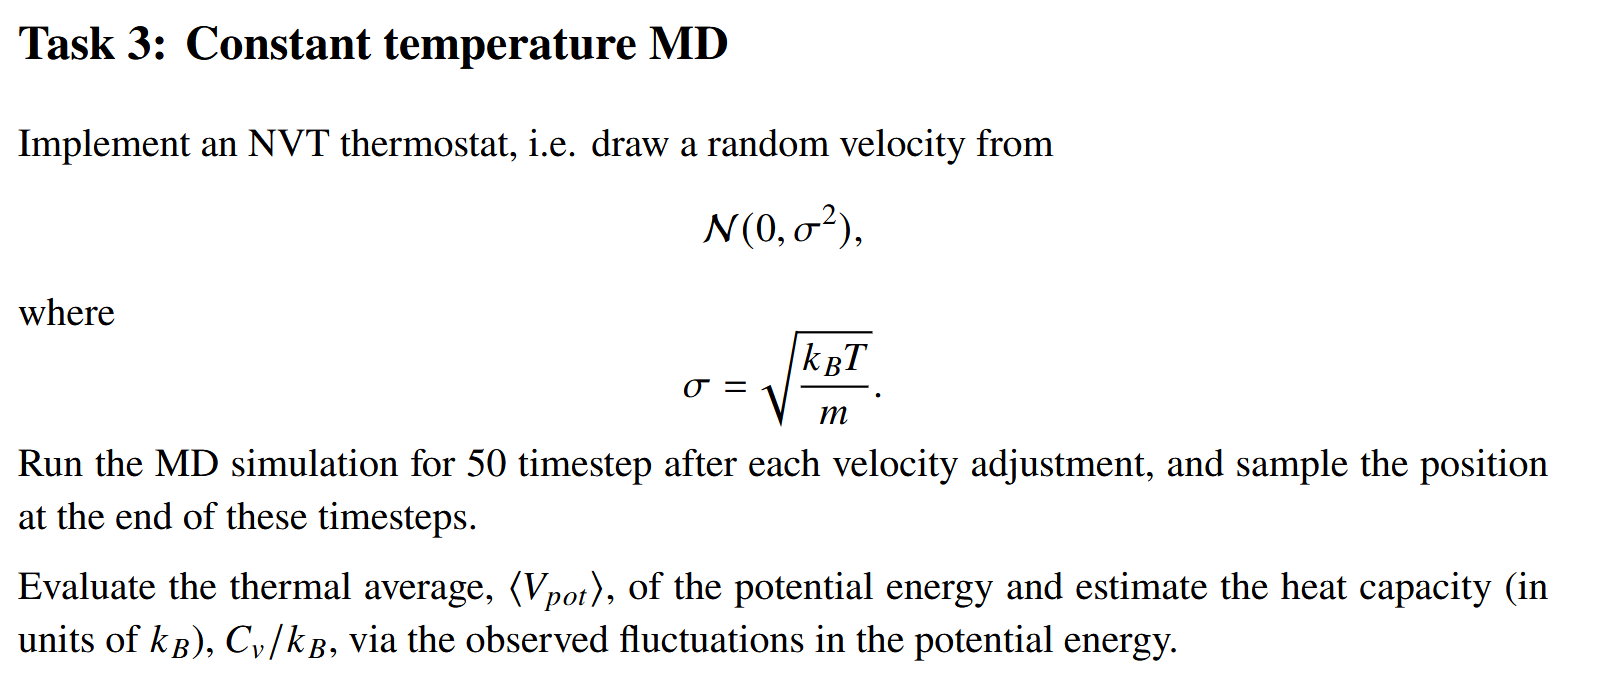

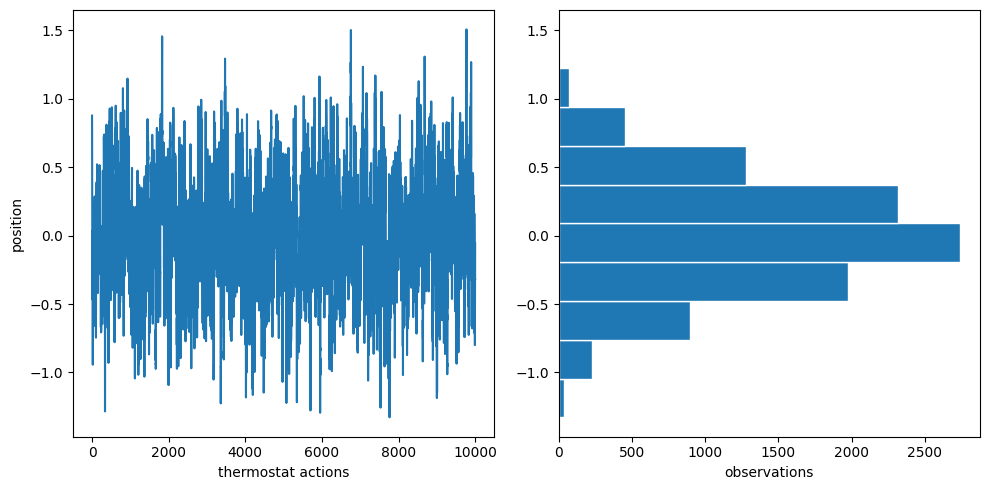

In [3]:
def thermostat(md):
    scale = np.sqrt(md.kT) # Assume m=1
    v = np.random.normal(0, scale)
    md.set_velocity(v)

md = MolDynSys(calc, x=1)

xs = []
for _ in range(N):
    x = velocity_verlet(md, 50)

    xs.append(x[-1])

    thermostat(md)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ax = axes[0]
ax.plot(n, xs)
ax.set_xlabel('thermostat actions')
ax.set_ylabel('position')

ax = axes[1]
ax.hist(xs, bins=10, orientation='horizontal', edgecolor='white')
ax.set_xlabel('observations')

plt.tight_layout()
